# Exploratory Data Analysis (EDA)

This notebook explores the Retail & E-Commerce Talent Pool dataset to understand candidate demographics, technical skills, career goals, and recruitment sources using Pandas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/retail_ecommerce_talent_pool_clean.csv")

In [3]:
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 681 entries, 0 to 680
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   candidate_id           681 non-null    int64 
 1   city                   681 non-null    object
 2   fresh_graduate_status  681 non-null    object
 3   skills                 681 non-null    object
 4   excel_skill            681 non-null    int64 
 5   sql_skill              681 non-null    int64 
 6   python_skill           681 non-null    int64 
 7   power_bi_skill         681 non-null    int64 
 8   looker_studio_skill    681 non-null    int64 
 9   database_skill         681 non-null    int64 
 10  tableau_skill          681 non-null    int64 
 11  other_skills           44 non-null     object
 12  candidate_goals        681 non-null    object
 13  platform_source        681 non-null    object
 14  province               681 non-null    object
 15  for_job                

In [12]:
goal_counts = pd.Series({
    "Looking for Job": df["for_job"].sum(),
    "Upskilling": df["upskills"].sum(),
    "Networking": df["networking"].sum(),
    "Switch Career": df["switch_career"].sum()
})

goal_counts.sort_values(ascending=False)

Upskilling         622
Networking         522
Looking for Job    450
Switch Career      273
dtype: int64

In [14]:
pd.crosstab(
    df["province"],
    df["fresh_graduate_status"]
)

fresh_graduate_status,Tidak,Ya
province,,
Aceh,1,1
Bali,1,0
Bangka Belitung,0,3
Banten,25,31
Belum ada mapping,2,1
Bengkulu,1,5
DI Yogyakarta,11,17
Jakarta,68,44
Jambi,2,3


In [15]:
pd.crosstab(
    df["fresh_graduate_status"],
    df["sql_skill"]
)

sql_skill,0,1
fresh_graduate_status,,
Tidak,62,233
Ya,58,328


In [16]:
skill_summary = pd.DataFrame({
    "Skill": [
        "Excel",
        "SQL",
        "Python",
        "Power BI",
        "Looker Studio",
        "Database",
        "Tableau",
        "Other Skills"
    ],
    "Total Candidates": [
        df["excel_skill"].sum(),
        df["sql_skill"].sum(),
        df["python_skill"].sum(),
        df["power_bi_skill"].sum(),
        df["looker_studio_skill"].sum(),
        df["database_skill"].sum(),
        df["tableau_skill"].sum(),
        df["other_skills"].notna().sum()
    ]
})

skill_summary.sort_values("Total Candidates", ascending=False)

,Skill,Total Candidates
1,SQL,561
2,Python,549
0,Excel,527
3,Power BI,516
5,Database,491
6,Tableau,446
4,Looker Studio,401
7,Other Skills,44


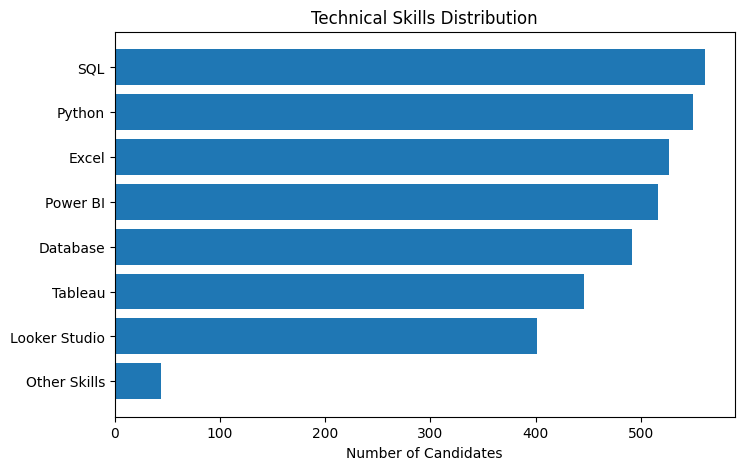

In [17]:
skill_summary = skill_summary.sort_values(
    "Total Candidates",
    ascending=True
)

plt.figure(figsize=(8,5))

plt.barh(
    skill_summary["Skill"],
    skill_summary["Total Candidates"]
)

plt.title("Technical Skills Distribution")
plt.xlabel("Number of Candidates")

plt.show()

In [18]:
goal_summary = pd.DataFrame({
    "Goal":[
        "Looking for Job",
        "Upskilling",
        "Networking",
        "Career Switch"
    ],
    "Total Candidates":[
        df["for_job"].sum(),
        df["upskills"].sum(),
        df["networking"].sum(),
        df["switch_career"].sum()
    ]
})

goal_summary

,Goal,Total Candidates
0,Looking for Job,450
1,Upskilling,622
2,Networking,522
3,Career Switch,273


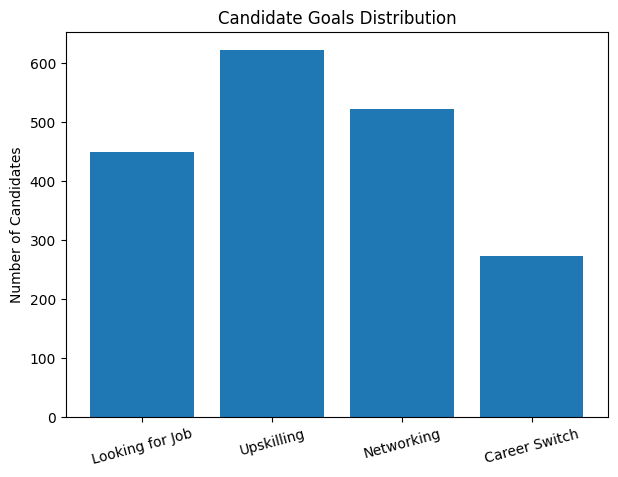

In [19]:
plt.figure(figsize=(7,5))

plt.bar(
    goal_summary["Goal"],
    goal_summary["Total Candidates"]
)

plt.title("Candidate Goals Distribution")
plt.ylabel("Number of Candidates")

plt.xticks(rotation=15)

plt.show()

In [20]:
province_summary = (
    df["province"]
      .value_counts()
      .reset_index()
)

province_summary.columns = [
    "Province",
    "Total Candidates"
]

province_summary.head(10)

,Province,Total Candidates
0,Jawa Barat,173
1,Jakarta,112
2,Jawa Timur,96
3,Jawa Tengah,70
4,Banten,56
5,DI Yogyakarta,28
6,Sumatera Utara,19
7,Riau,19
8,Sulawesi Selatan,14
9,Sumatera Barat,12


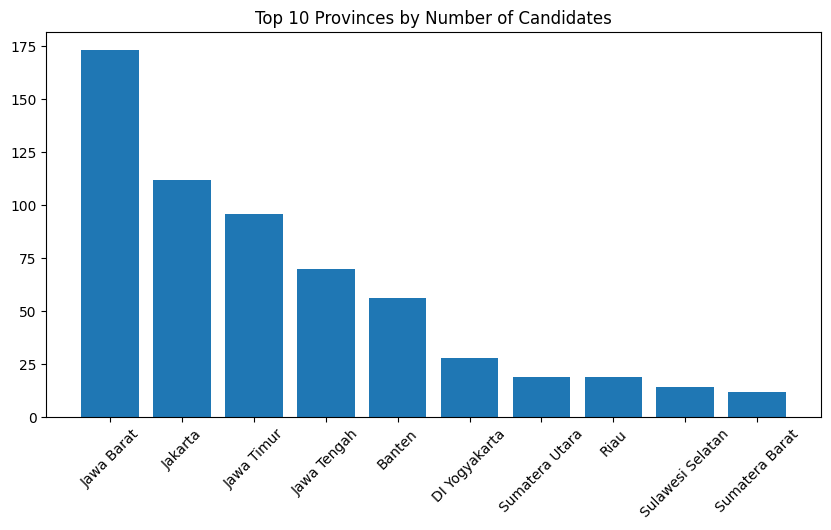

In [21]:
top10 = province_summary.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["Province"],
    top10["Total Candidates"]
)

plt.title("Top 10 Provinces by Number of Candidates")

plt.xticks(rotation=45)

plt.show()

In [22]:
platform_summary = (
    df["platform_source"]
      .value_counts()
      .reset_index()
)

platform_summary.columns = [
    "Platform",
    "Total Candidates"
]

platform_summary

,Platform,Total Candidates
0,LinkedIn,549
1,Teman,80
2,Instagram,52


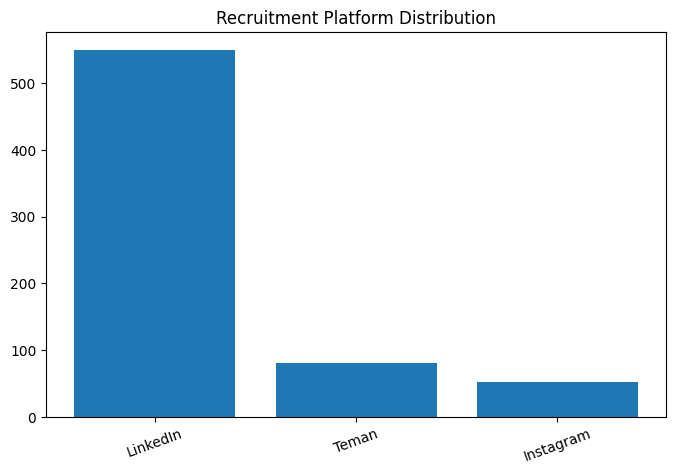

In [23]:
plt.figure(figsize=(8,5))

plt.bar(
    platform_summary["Platform"],
    platform_summary["Total Candidates"]
)

plt.title("Recruitment Platform Distribution")

plt.xticks(rotation=20)

plt.show()

In [24]:
df["total_skills"] = (
    df["excel_skill"] +
    df["sql_skill"] +
    df["python_skill"] +
    df["power_bi_skill"] +
    df["looker_studio_skill"] +
    df["database_skill"] +
    df["tableau_skill"]
)

In [25]:
df["skill_level"] = pd.cut(
    df["total_skills"],
    bins=[-1,2,5,7],
    labels=[
        "Beginner",
        "Intermediate",
        "Advanced"
    ]
)

In [26]:
df["skill_level"].value_counts()

skill_level
Advanced        332
Intermediate    283
Beginner         66
Name: count, dtype: int64